# Eksperyment: Wpływ funkcji straty na wyniki MLP

W tym notatniku zbadamy wpływ funkcji straty na proces uczenia modelu MLP.

Dla zadania klasyfikacji porównamy dwie funkcje straty: entropię krzyżową (cross-entropy) oraz błąd średniokwadratowy (MSE). Dla zadania regresji porównujemy MSE oraz MAE (Mean Absolute Error).

In [11]:
# from mlp.mlp import MLP
# from mlp.utils import plot_accuracy
# import inspect
#
# # print(inspect.getsource(plot_accuracy))
# print(inspect.getsource(MLP.__init__))

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from mlp.mlp import MLP
from mlp.utils import (
    load_dataset, plot_dataset, plot_loss, plot_accuracy,
    plot_decision_boundary, plot_weights_together, accuracy, mse
)


In [13]:
# === 1. Konfiguracja ===

datasets = {
    # --- Klasyfikacja ---
    "simple": {
        "path": "../lab1_data/Classification/data.simple.train.1000.csv",
        "task": "binary",
        "losses": ["mse", "binary_cross_entropy"],
        "activation": "gelu",
        "learning_rate": 0.01,
    },
    "three_gauss": {
        "path": "../lab1_data/Classification/data.three_gauss.train.1000.csv",
        "task": "multiclass",
        "losses": ["mse", "categorical_cross_entropy"],
        "activation": "gelu",
        "learning_rate": 0.01,
    },
    # --- Regresja ---
    "activation": {
        "path": "../lab1_data/Regression/data.activation.train.1000.csv",
        "task": "regression",
        "losses": ["mse", "mae"],
        "activation": "gelu",
        "learning_rate": 0.001,
    },
    "cube": {
        "path": "../lab1_data/Regression/data.cube.train.1000.csv",
        "task": "regression",
        "losses": ["mse", "mae"],
        "activation": "gelu",
        "learning_rate": 0.001,
    }
}

epochs = 500
results = {}


=== Dataset: SIMPLE ===
[load_dataset] Detected CLASSIFICATION: unique labels [0 1]


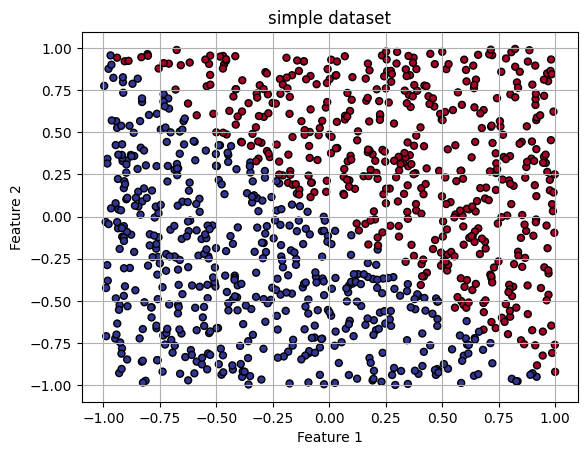


--- Training with loss: mse ---


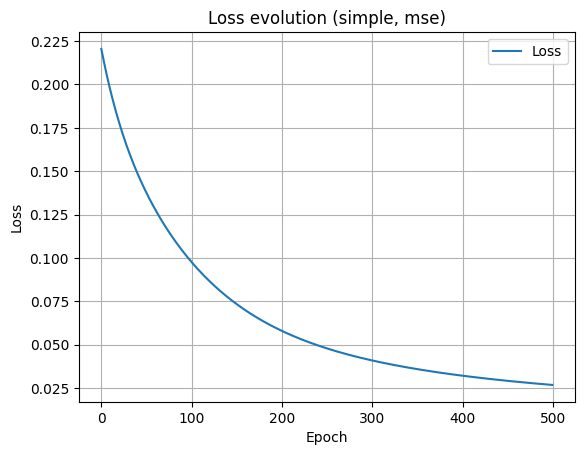

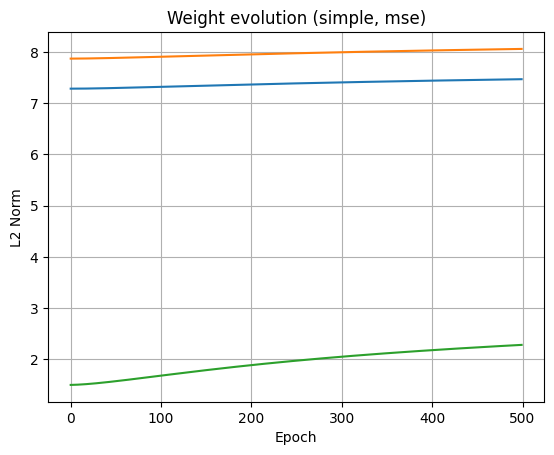

Final accuracy (mse): 0.9890


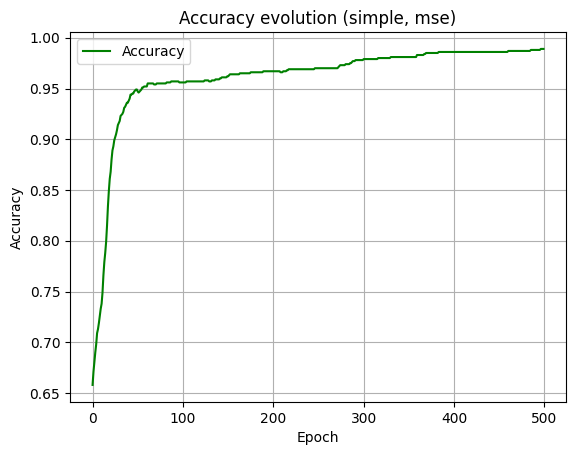

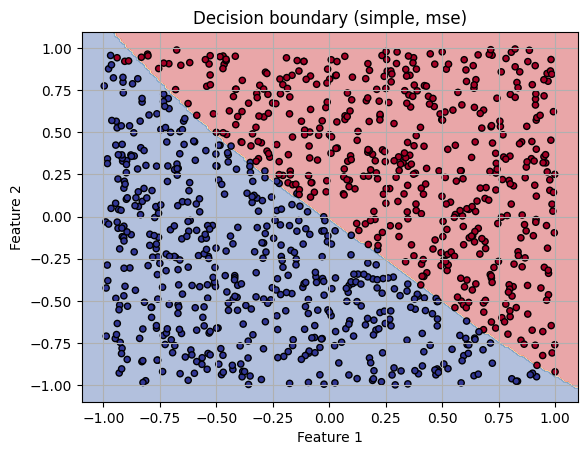


--- Training with loss: binary_cross_entropy ---


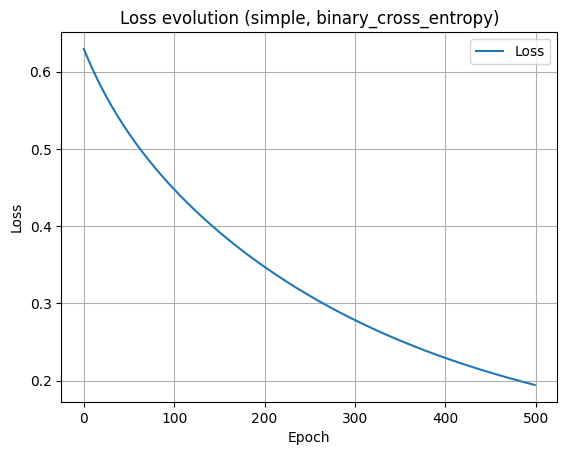

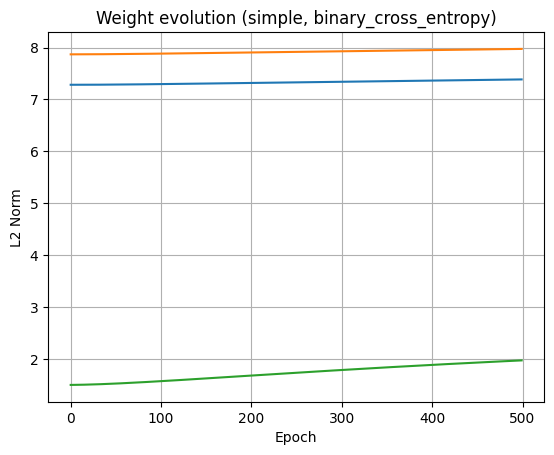

Final accuracy (binary_cross_entropy): 0.9700


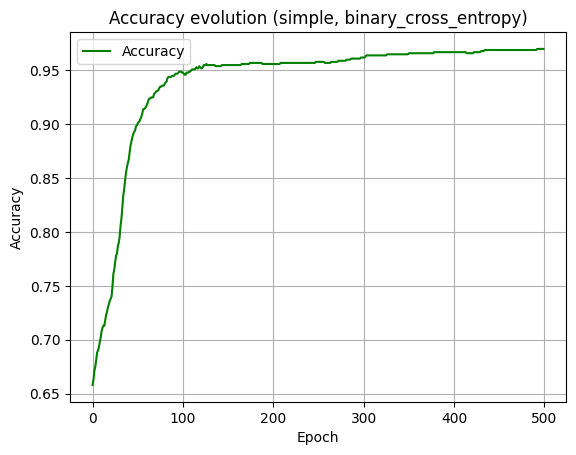

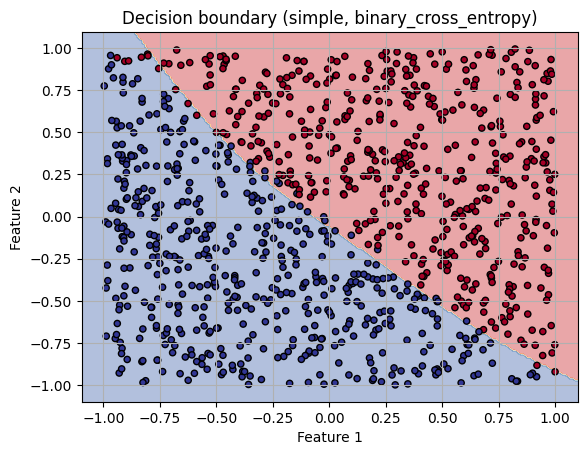


=== Dataset: THREE_GAUSS ===
[load_dataset] Detected CLASSIFICATION: unique labels [0 1 2]


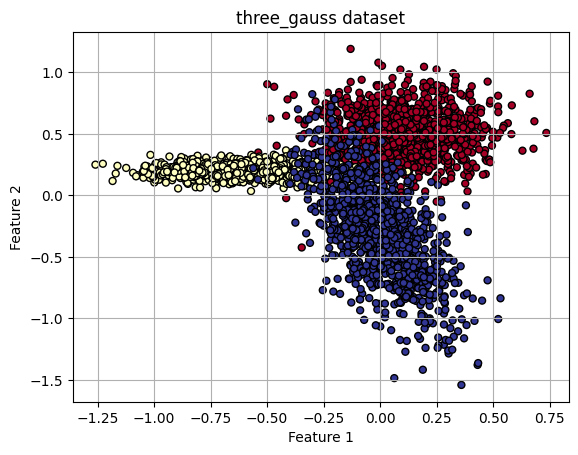


--- Training with loss: mse ---


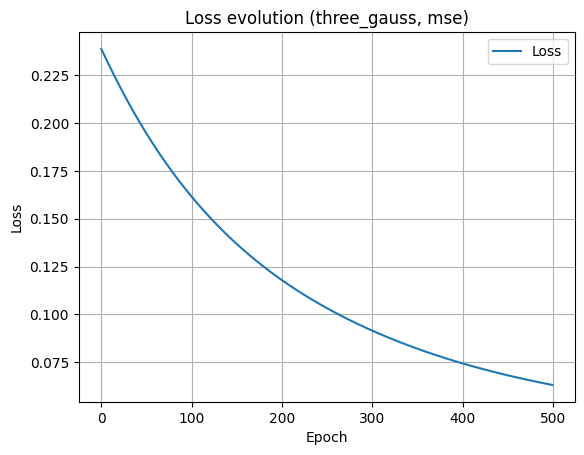

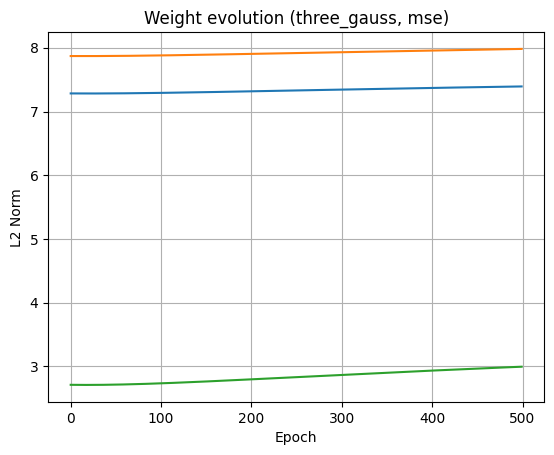

Final accuracy (mse): 0.9063


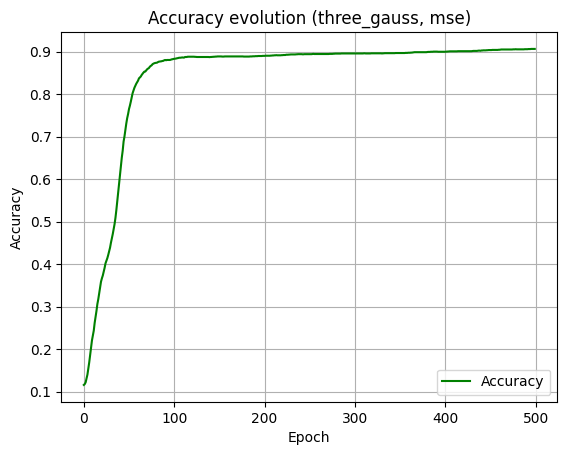

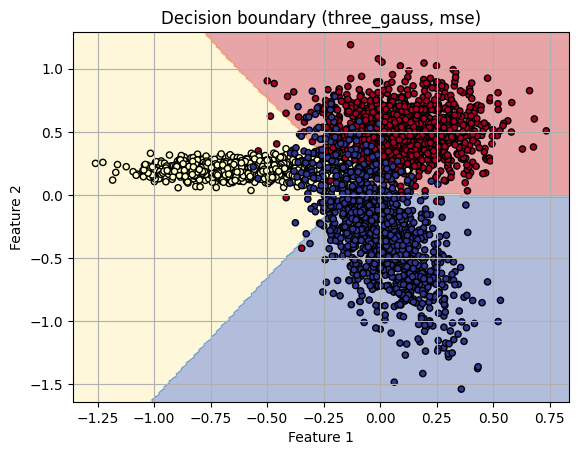


--- Training with loss: categorical_cross_entropy ---


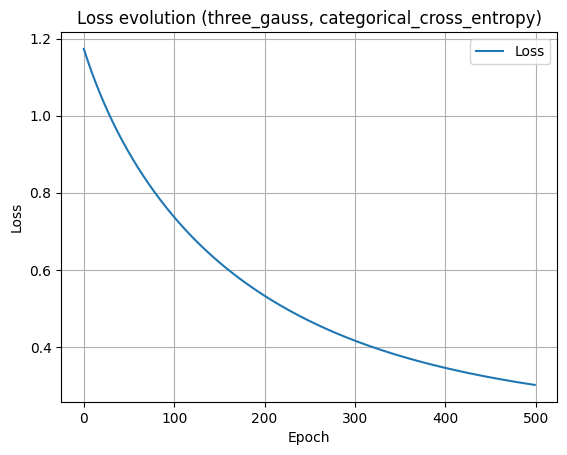

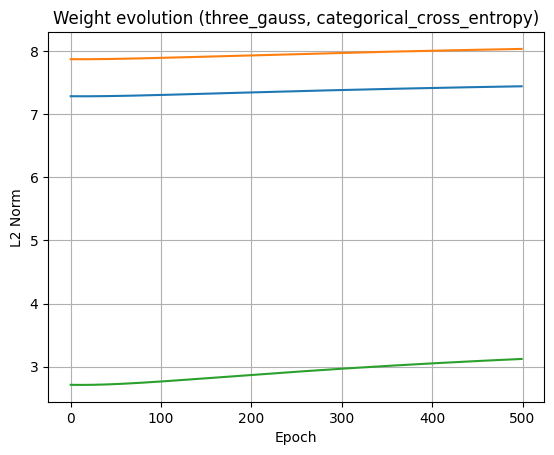

Final accuracy (categorical_cross_entropy): 0.9180


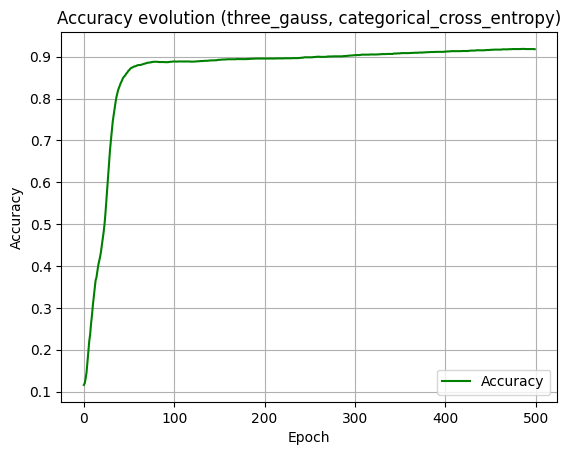

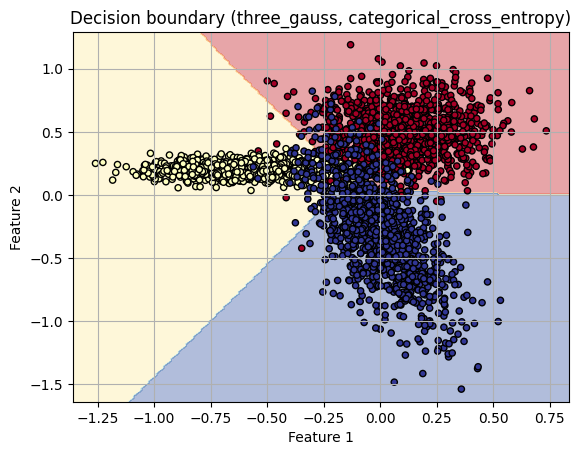


=== Dataset: ACTIVATION ===
[load_dataset] Detected REGRESSION: normalized target (mean=-93.366, std=89.163)


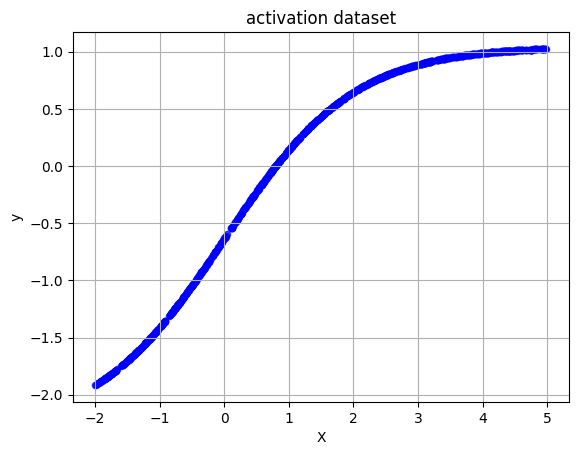


--- Training with loss: mse ---


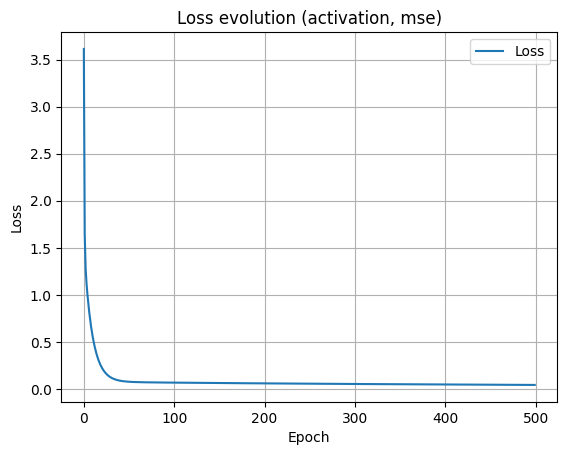

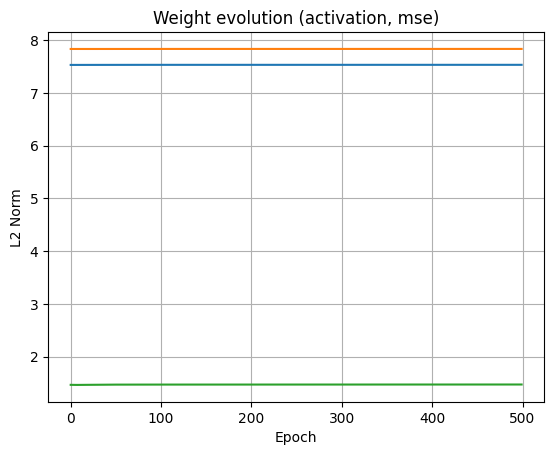

Final MSE (mse): 0.0436

--- Training with loss: mae ---


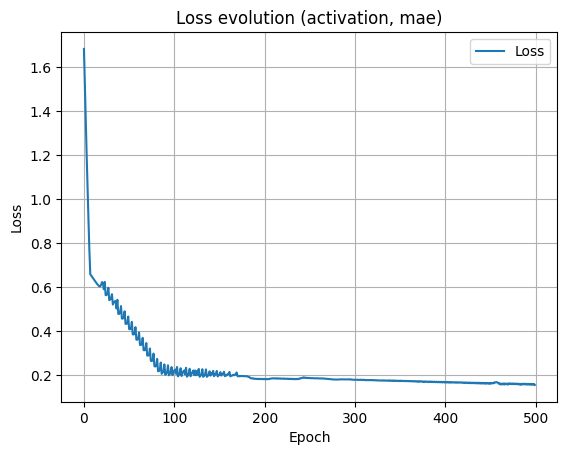

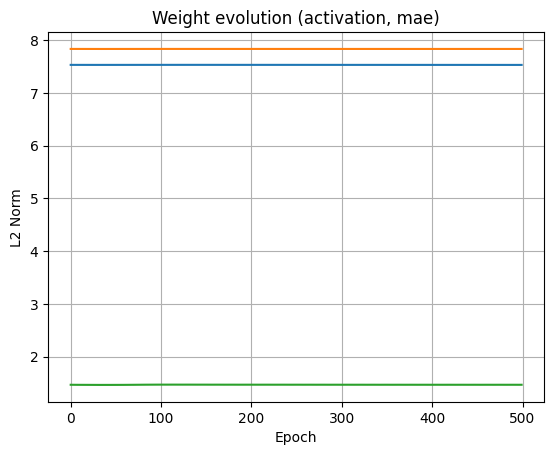

Final MSE (mae): 0.0443

=== Dataset: CUBE ===
[load_dataset] Detected REGRESSION: normalized target (mean=-14.537, std=51.355)


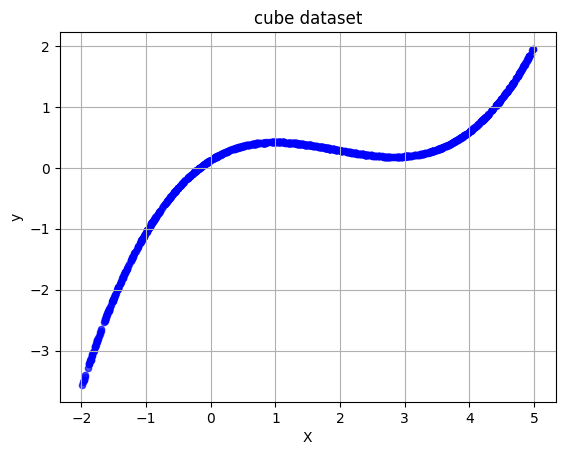


--- Training with loss: mse ---


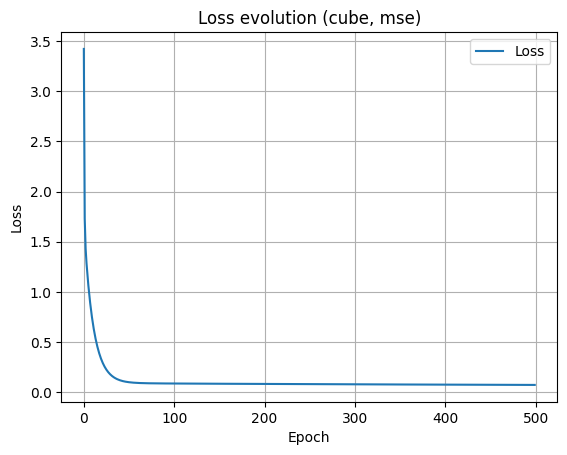

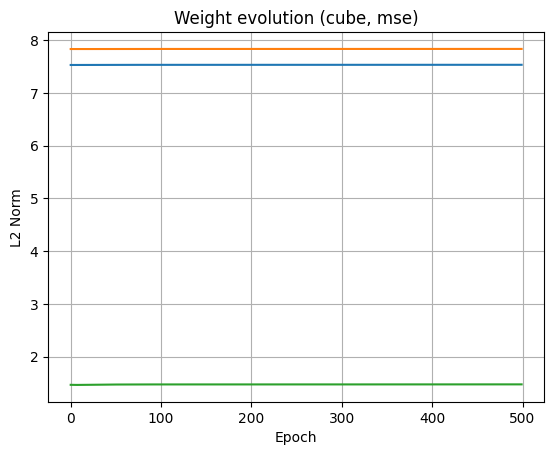

Final MSE (mse): 0.0736

--- Training with loss: mae ---


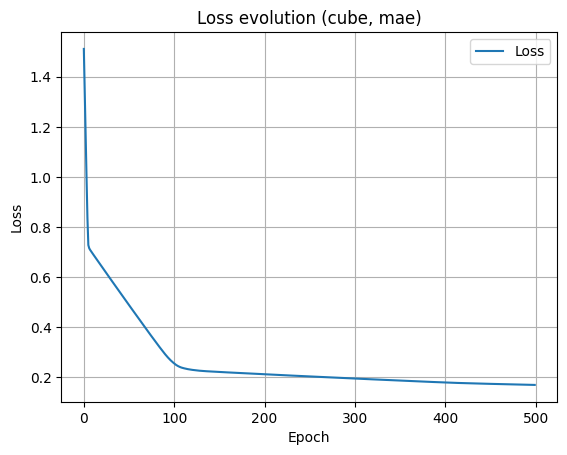

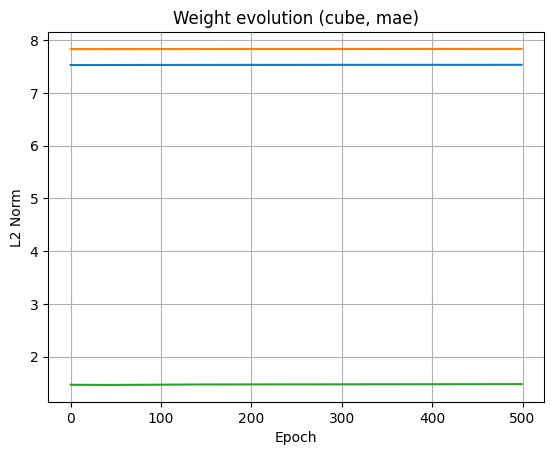

Final MSE (mae): 0.0880


In [14]:
# === 2. Eksperyment główny ===

for dataset_name, cfg in datasets.items():
    print(f"\n=== Dataset: {dataset_name.upper()} ===")
    X, y = load_dataset(cfg["path"])
    plot_dataset(X, y, title=f"{dataset_name} dataset")

    results[dataset_name] = {}

    for loss in cfg["losses"]:
        print(f"\n--- Training with loss: {loss} ---")
        model = MLP(
            layer_sizes=[X.shape[1], 32, 32, (1 if cfg["task"] != "multiclass" else len(np.unique(y)))],
            task=cfg["task"],
            activation=cfg["activation"],
            learning_rate=cfg["learning_rate"],
            loss=loss,
            seed=42
        )

        history, weight_history, acc_history = model.fit(X, y, epochs=epochs, verbose=False)
        results[dataset_name][loss] = {
            "model": model,
            "loss_history": history,
            "weight_history": weight_history,
            "acc_history": acc_history,
        }

        # --- Wizualizacje ---
        plot_loss(history, title=f"Loss evolution ({dataset_name}, {loss})")
        plot_weights_together(weight_history, title=f"Weight evolution ({dataset_name}, {loss})")

        if cfg["task"] in ["binary", "multiclass"]:
            preds = model.predict(X)
            acc_val = accuracy(y, preds)
            print(f"Final accuracy ({loss}): {acc_val:.4f}")
            plot_accuracy(acc_history, title=f"Accuracy evolution ({dataset_name}, {loss})")
            plot_decision_boundary(model, X, y, title=f"Decision boundary ({dataset_name}, {loss})")
        else:
            y_pred = model.predict(X)
            mse_val = mse(y, y_pred)
            print(f"Final MSE ({loss}): {mse_val:.4f}")

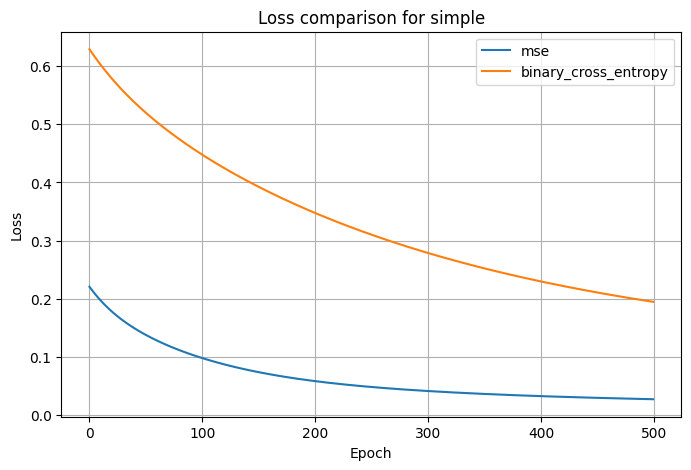

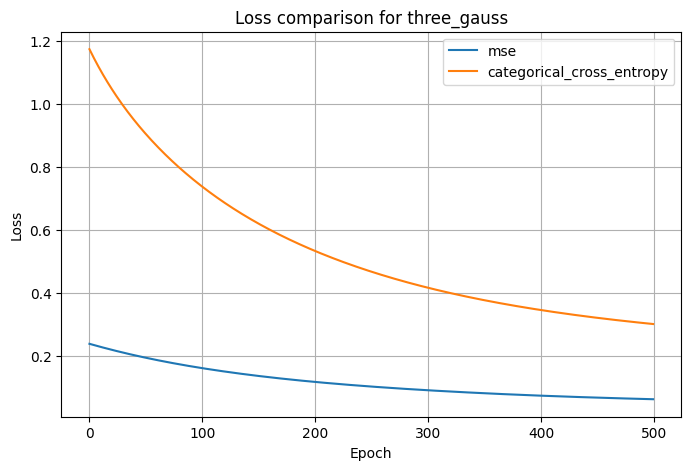

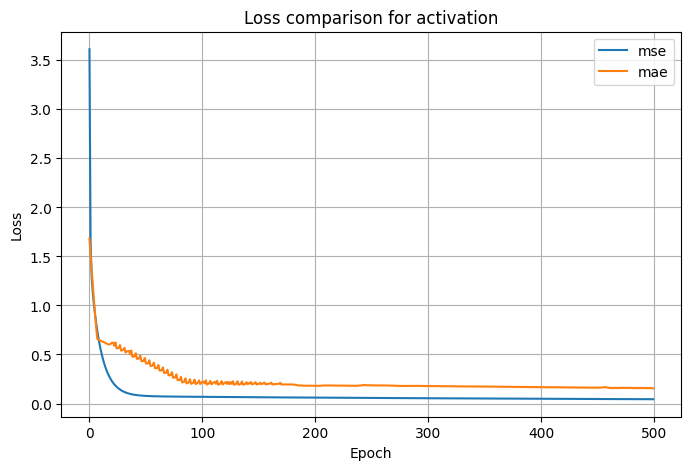

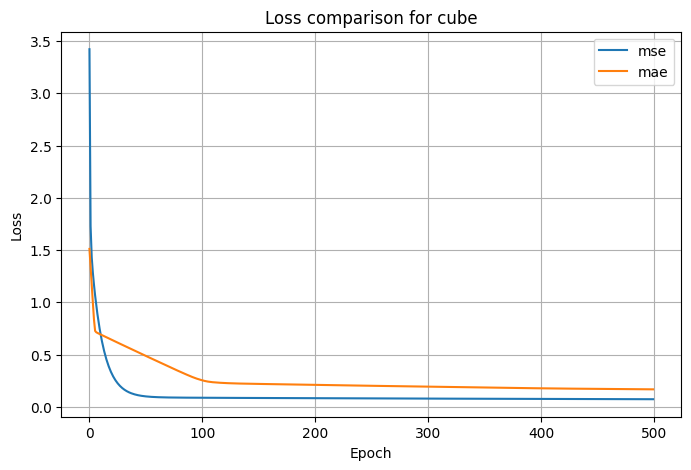

In [15]:
# === 3. Porównanie funkcji strat w obrębie zbioru ===
for dataset_name, res in results.items():
    plt.figure(figsize=(8, 5))
    for loss, data in res.items():
        plt.plot(data["loss_history"], label=loss)
    plt.title(f"Loss comparison for {dataset_name}")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()